# Project


#### Ссылка на данные: https://www.kaggle.com/datasets/fedesoriano/company-bankruptcy-prediction

##Описание проекта:
###Прогнозирование банкротства компании

###Задача: бинарная классификация (банкротство или не банкротство)

###План работы:
1. Загрузка датасета, первичный обзор данных
2. Разведочный анализ данных: корреляция экономических признаков компаний с банкротством, корреляция признаков между собой, отбор признаков
3. Подготовка данных
4. Обучение моделей
5. Сравнение моделей
6. Выбор ключевых признаков банкротства
7. Вывод




#1. Загрузка данных, первичный обзор


In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("fedesoriano/company-bankruptcy-prediction")

print("Path to dataset files:", path)


100%|██████████| 4.63M/4.63M [00:00<00:00, 69.4MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/fedesoriano/company-bankruptcy-prediction/versions/2


In [2]:
import os
os.listdir(path)


['data.csv']

In [3]:
print(path)

/root/.cache/kagglehub/datasets/fedesoriano/company-bankruptcy-prediction/versions/2


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import seaborn as sns

**Первичный обзори датасета**

In [5]:
df_companies = pd.read_csv("/root/.cache/kagglehub/datasets/fedesoriano/company-bankruptcy-prediction/versions/2/data.csv", low_memory=False)

df_companies.head()

,Bankrupt?,ROA(C) before interest and depreciation before interest,ROA(A) before interest and % after tax,ROA(B) before interest and depreciation after tax,Operating Gross Margin,Realized Sales Gross Margin,Operating Profit Rate,Pre-tax net Interest Rate,After-tax net Interest Rate,Non-industry income and expenditure/revenue,...,Net Income to Total Assets,Total assets to GNP price,No-credit Interval,Gross Profit to Sales,Net Income to Stockholder's Equity,Liability to Equity,Degree of Financial Leverage (DFL),Interest Coverage Ratio (Interest expense to EBIT),Net Income Flag,Equity to Liability
0,1,0.370594,0.424389,0.405750,0.601457,0.601457,0.998969,0.796887,0.808809,0.302646,...,0.716845,0.009219,0.622879,0.601453,0.827890,0.290202,0.026601,0.564050,1,0.016469
1,1,0.464291,0.538214,0.516730,0.610235,0.610235,0.998946,0.797380,0.809301,0.303556,...,0.795297,0.008323,0.623652,0.610237,0.839969,0.283846,0.264577,0.570175,1,0.020794
2,1,0.426071,0.499019,0.472295,0.601450,0.601364,0.998857,0.796403,0.808388,0.302035,...,0.774670,0.040003,0.623841,0.601449,0.836774,0.290189,0.026555,0.563706,1,0.016474
3,1,0.399844,0.451265,0.457733,0.583541,0.583541,0.998700,0.796967,0.808966,0.303350,...,0.739555,0.003252,0.622929,0.583538,0.834697,0.281721,0.026697,0.564663,1,0.023982
4,1,0.465022,0.538432,0.522298,0.598783,0.598783,0.998973,0.797366,0.809304,0.303475,...,0.795016,0.003878,0.623521,0.598782,0.839973,0.278514,0.024752,0.575617,1,0.035490


In [6]:
df_companies.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6819 entries, 0 to 6818
Data columns (total 96 columns):
 #   Column                                                    Non-Null Count  Dtype  
---  ------                                                    --------------  -----  
 0   Bankrupt?                                                 6819 non-null   int64  
 1    ROA(C) before interest and depreciation before interest  6819 non-null   float64
 2    ROA(A) before interest and % after tax                   6819 non-null   float64
 3    ROA(B) before interest and depreciation after tax        6819 non-null   float64
 4    Operating Gross Margin                                   6819 non-null   float64
 5    Realized Sales Gross Margin                              6819 non-null   float64
 6    Operating Profit Rate                                    6819 non-null   float64
 7    Pre-tax net Interest Rate                                6819 non-null   float64
 8    After-tax net Int

In [7]:
print(df_companies.shape)

(6819, 96)


In [8]:
df_companies.isnull().sum()

,0
Bankrupt?,0
ROA(C) before interest and depreciation before interest,0
ROA(A) before interest and % after tax,0
ROA(B) before interest and depreciation after tax,0
Operating Gross Margin,0
...,...
Liability to Equity,0
Degree of Financial Leverage (DFL),0
Interest Coverage Ratio (Interest expense to EBIT),0
Net Income Flag,0


Важно заметить, что в данных нет пропусков

In [9]:
df_companies['Bankrupt?'].value_counts()

,count
Bankrupt?,
0,6599
1,220


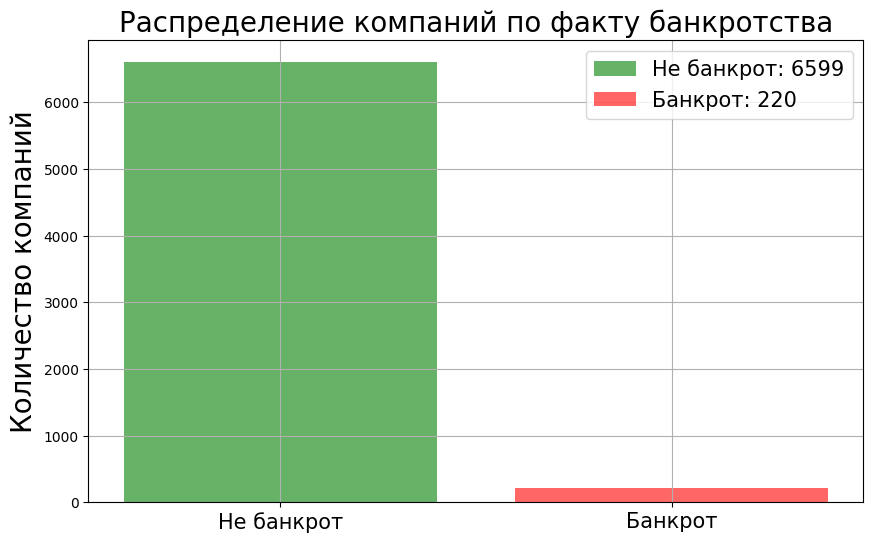

In [10]:
bankrupt_counts = df_companies['Bankrupt?'].value_counts()

plt.figure(figsize=(10, 6))

plt.bar('Не банкрот', bankrupt_counts[0], color='green', label=f'Не банкрот: {bankrupt_counts[0]}', alpha=0.6)
plt.bar('Банкрот', bankrupt_counts[1], color='red', label=f'Банкрот: {bankrupt_counts[1]}',alpha=0.6)


plt.ylabel("Количество компаний", fontsize=20)
plt.title("Распределение компаний по факту банкротства", fontsize = 20)



plt.legend(fontsize = 15)
plt.xticks(fontsize = 15)
plt.grid(True)
plt.show()

In [11]:
print(f'Процент компаний-банкротов = {(bankrupt_counts[1]/df_companies.shape[0] * 100):.2f}%')

Процент компаний-банкротов = 3.23%


Такой низкий процент показывает дизбаланс классов. Скорее всего это сильно скажется на результатах.


#2. Резведочный анализ данных

In [12]:
df_companies.columns = df_companies.columns.str.strip()
for col in df_companies.columns:
    print(col)

Bankrupt?
ROA(C) before interest and depreciation before interest
ROA(A) before interest and % after tax
ROA(B) before interest and depreciation after tax
Operating Gross Margin
Realized Sales Gross Margin
Operating Profit Rate
Pre-tax net Interest Rate
After-tax net Interest Rate
Non-industry income and expenditure/revenue
Continuous interest rate (after tax)
Operating Expense Rate
Research and development expense rate
Cash flow rate
Interest-bearing debt interest rate
Tax rate (A)
Net Value Per Share (B)
Net Value Per Share (A)
Net Value Per Share (C)
Persistent EPS in the Last Four Seasons
Cash Flow Per Share
Revenue Per Share (Yuan ¥)
Operating Profit Per Share (Yuan ¥)
Per Share Net profit before tax (Yuan ¥)
Realized Sales Gross Profit Growth Rate
Operating Profit Growth Rate
After-tax Net Profit Growth Rate
Regular Net Profit Growth Rate
Continuous Net Profit Growth Rate
Total Asset Growth Rate
Net Value Growth Rate
Total Asset Return Growth Rate Ratio
Cash Reinvestment %
Curren

##Показатели прибыльности (Profitability)


| Признак                                                   | Перевод                                           | Краткое описание                               |
| --------------------------------------------------------- | ------------------------------------------------- | ---------------------------------------------- |
| `ROA(C) before interest and depreciation before interest` | Рентабельность активов до процентов и амортизации | Показывает эффективность использования активов |
| `ROA(A) before interest and % after tax`                  | ROA после налогообложения                         | Чистая прибыль относительно активов            |
| `ROA(B) before interest and depreciation after tax`       | ROA после налогов и амортизации                   | Доходность активов после налогов               |
| `Operating Gross Margin`                                  | Операционная валовая маржа                        | Доля валовой прибыли в выручке                 |
| `Realized Sales Gross Margin`                             | Реализованная валовая маржа продаж                | Реальная прибыльность продаж                   |
| `Operating Profit Rate`                                   | Операционная рентабельность                       | Эффективность основной деятельности            |
| `Pre-tax net Interest Rate`                               | Чистая прибыль до налогов                         | Прибыльность до налогообложения                |
| `After-tax net Interest Rate`                             | Чистая прибыль после налогов                      | Итоговая прибыльность компании                 |
| `Operating profit/Paid-in capital`                        | Операционная прибыль к капиталу                   | Доходность вложенного капитала                 |
| `Net profit before tax/Paid-in capital`                   | Прибыль до налогов к капиталу                     | Эффективность использования капитала           |
| `Gross Profit to Sales`                                   | Валовая прибыль к продажам                        | Общая прибыльность продаж                      |
| `Net Income to Stockholder's Equity`                      | Чистая прибыль к собственному капиталу            | ROE — доходность капитала акционеров           |
| `Net Income to Total Assets`                              | Чистая прибыль к активам                          | Итоговая рентабельность активов                |


##Показатели роста (Growth)

| Признак                                   | Перевод                           | Описание                    |
| ----------------------------------------- | --------------------------------- | --------------------------- |
| `Realized Sales Gross Profit Growth Rate` | Рост валовой прибыли              | Изменение прибыли от продаж |
| `Operating Profit Growth Rate`            | Рост операционной прибыли         | Рост эффективности бизнеса  |
| `After-tax Net Profit Growth Rate`        | Рост чистой прибыли после налогов | Динамика чистой прибыли     |
| `Regular Net Profit Growth Rate`          | Рост регулярной прибыли           | Стабильный рост прибыли     |
| `Continuous Net Profit Growth Rate`       | Непрерывный рост прибыли          | Устойчивость роста          |
| `Total Asset Growth Rate`                 | Рост активов                      | Изменение объёма активов    |
| `Net Value Growth Rate`                   | Рост собственного капитала        | Рост стоимости компании     |
| `Total Asset Return Growth Rate Ratio`    | Рост доходности активов           | Динамика ROA                |


##Показатели ликвидности (Liquidity)


| Признак                               | Перевод                                          | Описание                                  |
| ------------------------------------- | ------------------------------------------------ | ----------------------------------------- |
| `Current Ratio`                       | Коэффициент текущей ликвидности                  | Способность покрывать краткосрочные долги |
| `Quick Ratio`                         | Коэффициент быстрой ликвидности                  | Ликвидность без учета запасов             |
| `Cash/Current Liability`              | Денежные средства к краткосрочным обязательствам | Покрытие долгов наличными                 |
| `Quick Assets/Current Liability`      | Быстрые активы к краткосрочным обязательствам    | Возможность быстрого погашения долгов     |
| `Current Liability to Current Assets` | Краткосрочные обязательства к оборотным активам  | Риск нехватки ликвидности                 |
| `Working Capital to Total Assets`     | Оборотный капитал к активам                      | Финансовая устойчивость                   |
| `Working Capital/Equity`              | Оборотный капитал к капиталу                     | Обеспеченность капиталом                  |
| `Cash/Total Assets`                   | Денежные средства к активам                      | Доля ликвидных средств                    |


##Долговая нагрузка и финансовая устойчивость (Debt / Solvency)


| Признак                                 | Перевод                                            | Описание                                      |
| --------------------------------------- | -------------------------------------------------- | --------------------------------------------- |
| `Total debt/Total net worth`            | Долг к собственному капиталу                       | Финансовый рычаг                              |
| `Debt ratio %`                          | Доля долга                                         | Насколько компания зависит от заемных средств |
| `Net worth/Assets`                      | Собственный капитал к активам                      | Финансовая устойчивость                       |
| `Borrowing dependency`                  | Зависимость от заимствований                       | Степень кредитной зависимости                 |
| `Contingent liabilities/Net worth`      | Условные обязательства к капиталу                  | Потенциальные риски                           |
| `Current Liabilities/Liability`         | Краткосрочные обязательства к общим обязательствам | Структура долга                               |
| `Current Liabilities/Equity`            | Краткосрочные обязательства к капиталу             | Финансовое давление                           |
| `Liability to Equity`                   | Обязательства к капиталу                           | Debt-to-equity ratio                          |
| `Equity to Liability`                   | Капитал к обязательствам                           | Устойчивость компании                         |
| `Equity to Long-term Liability`         | Капитал к долгосрочным обязательствам              | Покрытие долгосрочного долга                  |
| `Long-term Liability to Current Assets` | Долгосрочные обязательства к оборотным активам     | Риск нехватки ликвидности                     |
| `Liability-Assets Flag`                 | Флаг превышения обязательств над активами          | Индикатор финансовой нестабильности           |


##Денежные потоки (Cash Flow)


| Признак                        | Перевод                                | Описание                                |
| ------------------------------ | -------------------------------------- | --------------------------------------- |
| `Cash flow rate`               | Темп денежного потока                  | Интенсивность движения денежных средств |
| `Cash Flow Per Share`          | Денежный поток на акцию                | Генерация cash flow                     |
| `Cash Reinvestment %`          | Реинвестирование денежных средств      | Доля reinvestment                       |
| `Operating Funds to Liability` | Операционные средства к обязательствам | Покрытие долгов cash flow               |
| `Cash Flow to Sales`           | Денежный поток к продажам              | Конверсия выручки в cash flow           |
| `Cash Flow to Total Assets`    | Денежный поток к активам               | Эффективность активов                   |
| `Cash Flow to Liability`       | Денежный поток к обязательствам        | Покрытие долгов cash flow               |
| `CFO to Assets`                | Операционный cash flow к активам       | Эффективность бизнеса                   |
| `Cash Flow to Equity`          | Денежный поток к капиталу              | Доходность капитала                     |


##Эффективность деятельности (Efficiency / Turnover)


| Признак                           | Перевод                                   | Описание                                 |
| --------------------------------- | ----------------------------------------- | ---------------------------------------- |
| `Total Asset Turnover`            | Оборачиваемость активов                   | Насколько эффективно используются активы |
| `Accounts Receivable Turnover`    | Оборачиваемость дебиторской задолженности | Скорость возврата долгов                 |
| `Average Collection Days`         | Средний срок погашения дебиторки          | Время возврата средств                   |
| `Inventory Turnover Rate (times)` | Оборачиваемость запасов                   | Скорость продажи запасов                 |
| `Fixed Assets Turnover Frequency` | Оборачиваемость основных средств          | Использование основных фондов            |
| `Net Worth Turnover Rate (times)` | Оборачиваемость капитала                  | Эффективность капитала                   |
| `Current Asset Turnover Rate`     | Оборачиваемость оборотных активов         | Эффективность оборотных средств          |
| `Quick Asset Turnover Rate`       | Оборачиваемость быстрых активов           | Скорость использования ликвидных активов |
| `Working capitcal Turnover Rate`  | Оборачиваемость оборотного капитала       | Эффективность оборотного капитала        |
| `Cash Turnover Rate`              | Оборачиваемость денежных средств          | Использование cash                       |


##Показатели на акцию (Per Share Metrics)


| Признак                                    | Перевод                       | Описание                    |
| ------------------------------------------ | ----------------------------- | --------------------------- |
| `Net Value Per Share (A/B/C)`              | Чистая стоимость на акцию     | Стоимость капитала на акцию |
| `Persistent EPS in the Last Four Seasons`  | EPS за последние 4 квартала   | Стабильность прибыли        |
| `Revenue Per Share (Yuan ¥)`               | Выручка на акцию              | Доходность акций            |
| `Operating Profit Per Share (Yuan ¥)`      | Операционная прибыль на акцию | Эффективность бизнеса       |
| `Per Share Net profit before tax (Yuan ¥)` | Прибыль до налогов на акцию   | Доходность акций            |


##Прочие показатели

| Признак                                              | Перевод                                      | Описание                         |
| ---------------------------------------------------- | -------------------------------------------- | -------------------------------- |
| `Research and development expense rate`              | Расходы на R&D                               | Инвестиции в развитие            |
| `Revenue per person`                                 | Выручка на сотрудника                        | Производительность труда         |
| `Operating profit per person`                        | Прибыль на сотрудника                        | Эффективность персонала          |
| `Allocation rate per person`                         | Ресурсы на сотрудника                        | Нагрузка на персонал             |
| `Fixed Assets to Assets`                             | Основные средства к активам                  | Структура активов                |
| `Total income/Total expense`                         | Доходы к расходам                            | Общая прибыльность               |
| `Total expense/Assets`                               | Расходы к активам                            | Эффективность затрат             |
| `No-credit Interval`                                 | Интервал без кредитования                    | Финансовая независимость         |
| `Degree of Financial Leverage (DFL)`                 | Степень финансового рычага                   | Чувствительность прибыли к долгу |
| `Interest Coverage Ratio (Interest expense to EBIT)` | Покрытие процентов прибылью                  | Способность обслуживать долг     |
| `Tax rate (A)`                                       | Налоговая ставка                             | Доля налогов                     |
| `Interest Expense Ratio`                             | Доля процентных расходов                     | Стоимость долга                  |
| `Interest-bearing debt interest rate`                | Ставка по процентному долгу                  | Цена заемных средств             |
| `Non-industry income and expenditure/revenue`        | Внереализационные доходы к выручке           | Доходы вне основной деятельности |
| `Continuous interest rate (after tax)`               | Непрерывная ставка после налогов             | Финансовая доходность            |
| `Inventory and accounts receivable/Net value`        | Запасы и дебиторка к капиталу                | Качество активов                 |
| `Long-term fund suitability ratio (A)`               | Соответствие долгосрочных фондов             | Устойчивость финансирования      |
| `Current Liability to Liability`                     | Краткосрочные обязательства к обязательствам | Структура долгов                 |
| `Current Liability to Assets`                        | Краткосрочные обязательства к активам        | Краткосрочная долговая нагрузка  |
| `Current Assets/Total Assets`                        | Оборотные активы к активам                   | Структура активов                |
| `Quick Assets/Total Assets`                          | Быстрые активы к активам                     | Ликвидность активов              |
| `Inventory/Working Capital`                          | Запасы к оборотному капиталу                 | Зависимость от запасов           |
| `Inventory/Current Liability`                        | Запасы к краткосрочным обязательствам        | Риск ликвидности                 |
| `Net Income Flag`                                    | Флаг положительной прибыли                   | Индикатор прибыльности           |
| `Total assets to GNP price`                          | Активы к ВНП                                 | Макроэкономическая привязка      |


In [13]:
df_companies.describe()

,Bankrupt?,ROA(C) before interest and depreciation before interest,ROA(A) before interest and % after tax,ROA(B) before interest and depreciation after tax,Operating Gross Margin,Realized Sales Gross Margin,Operating Profit Rate,Pre-tax net Interest Rate,After-tax net Interest Rate,Non-industry income and expenditure/revenue,...,Net Income to Total Assets,Total assets to GNP price,No-credit Interval,Gross Profit to Sales,Net Income to Stockholder's Equity,Liability to Equity,Degree of Financial Leverage (DFL),Interest Coverage Ratio (Interest expense to EBIT),Net Income Flag,Equity to Liability
count,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,...,6819.000000,6.819000e+03,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.0,6819.000000
mean,0.032263,0.505180,0.558625,0.553589,0.607948,0.607929,0.998755,0.797190,0.809084,0.303623,...,0.807760,1.862942e+07,0.623915,0.607946,0.840402,0.280365,0.027541,0.565358,1.0,0.047578
std,0.176710,0.060686,0.065620,0.061595,0.016934,0.016916,0.013010,0.012869,0.013601,0.011163,...,0.040332,3.764501e+08,0.012290,0.016934,0.014523,0.014463,0.015668,0.013214,0.0,0.050014
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.0,0.000000
25%,0.000000,0.476527,0.535543,0.527277,0.600445,0.600434,0.998969,0.797386,0.809312,0.303466,...,0.796750,9.036205e-04,0.623636,0.600443,0.840115,0.276944,0.026791,0.565158,1.0,0.024477
50%,0.000000,0.502706,0.559802,0.552278,0.605997,0.605976,0.999022,0.797464,0.809375,0.303525,...,0.810619,2.085213e-03,0.623879,0.605998,0.841179,0.278778,0.026808,0.565252,1.0,0.033798
75%,0.000000,0.535563,0.589157,0.584105,0.613914,0.613842,0.999095,0.797579,0.809469,0.303585,...,0.826455,5.269777e-03,0.624168,0.613913,0.842357,0.281449,0.026913,0.565725,1.0,0.052838
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,9.820000e+09,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.0,1.000000


In [14]:
bankrupt = df_companies[df_companies['Bankrupt?'] == 1]
non_bankrupt = df_companies[df_companies['Bankrupt?'] == 0]

**Выберем топ-20 признаков, коррелирующих с банкротством**

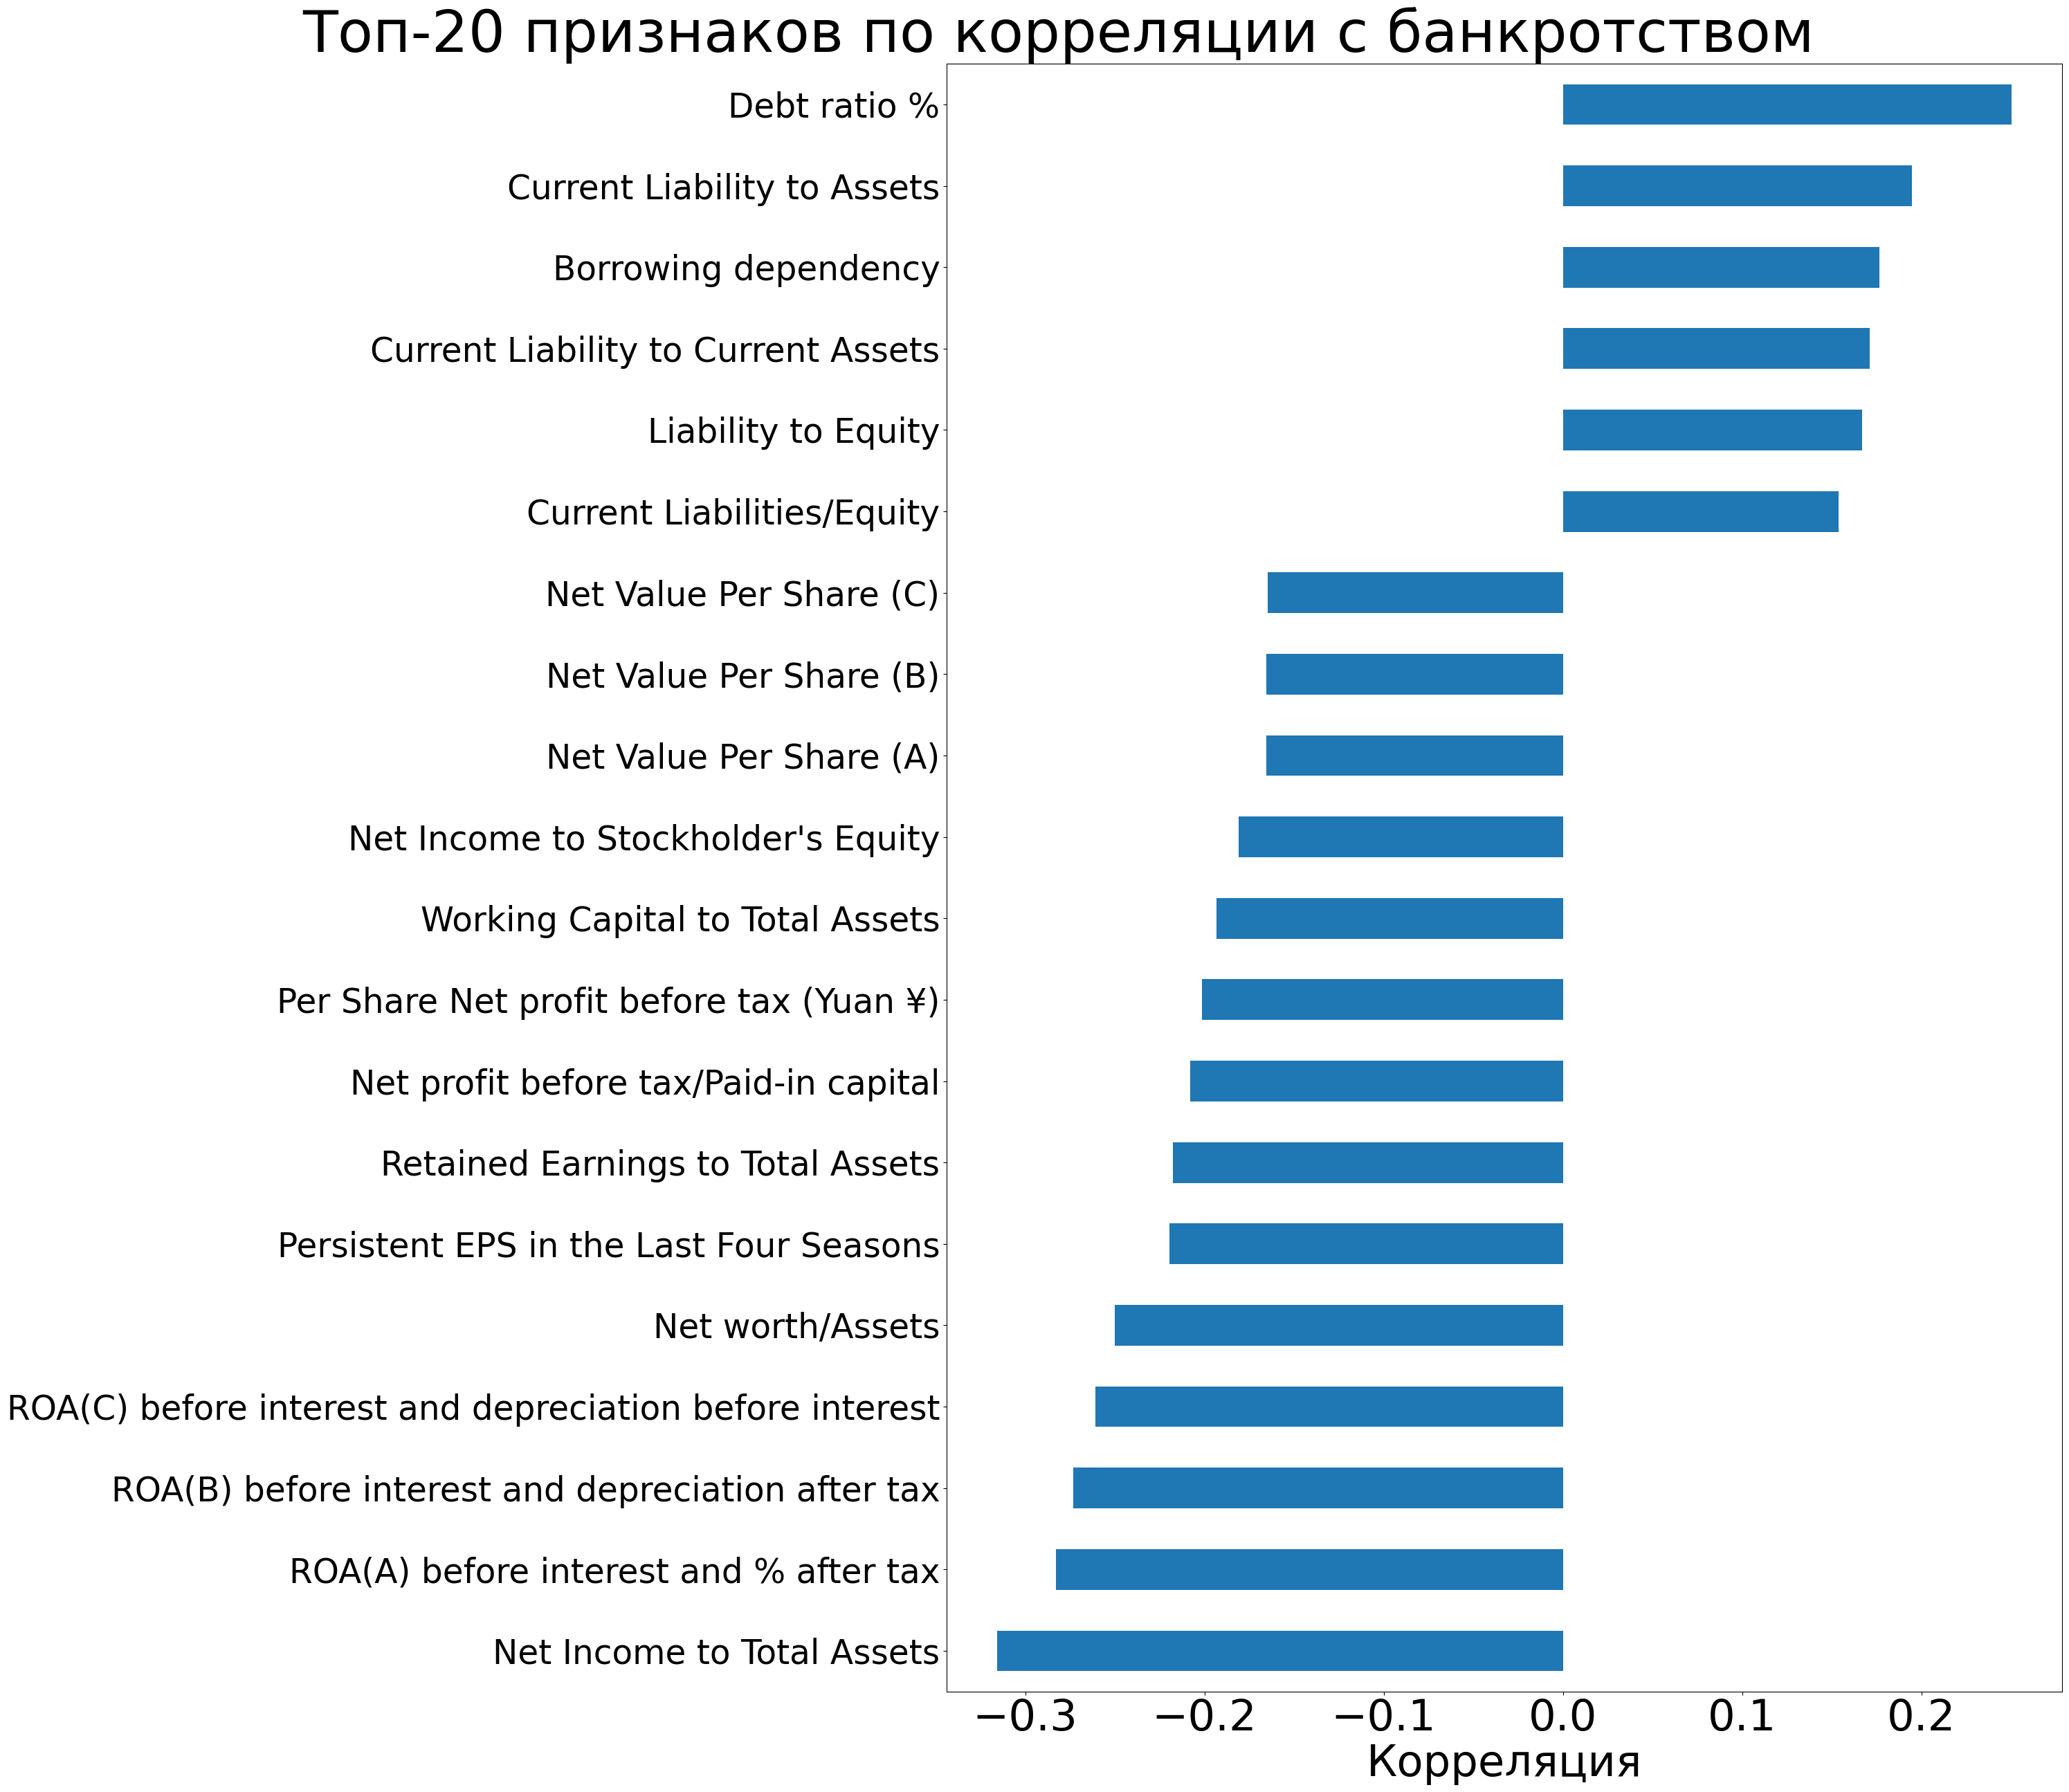

In [15]:
target_corr = df_companies.corr()['Bankrupt?'].drop('Bankrupt?')
top20 = target_corr.abs().nlargest(20).index
top20_vals = target_corr[top20].sort_values()


plt.figure(figsize=(30,26))
top20_vals.plot(kind = 'barh')


plt.title('Топ-20 признаков по корреляции с банкротством', fontsize=60, x=0.1)
plt.xlabel("Корреляция", fontsize=45)
plt.yticks(fontsize=35)
plt.xticks(fontsize=45)


plt.tight_layout()
plt.show()

In [16]:
top20_vals.abs().sort_values()

,Bankrupt?
Current Liabilities/Equity,0.153828
Net Value Per Share (C),0.164784
Net Value Per Share (B),0.165399
Net Value Per Share (A),0.165465
Liability to Equity,0.166812
Current Liability to Current Assets,0.171306
Borrowing dependency,0.176543
Net Income to Stockholder's Equity,0.180987
Working Capital to Total Assets,0.193083
Current Liability to Assets,0.194494


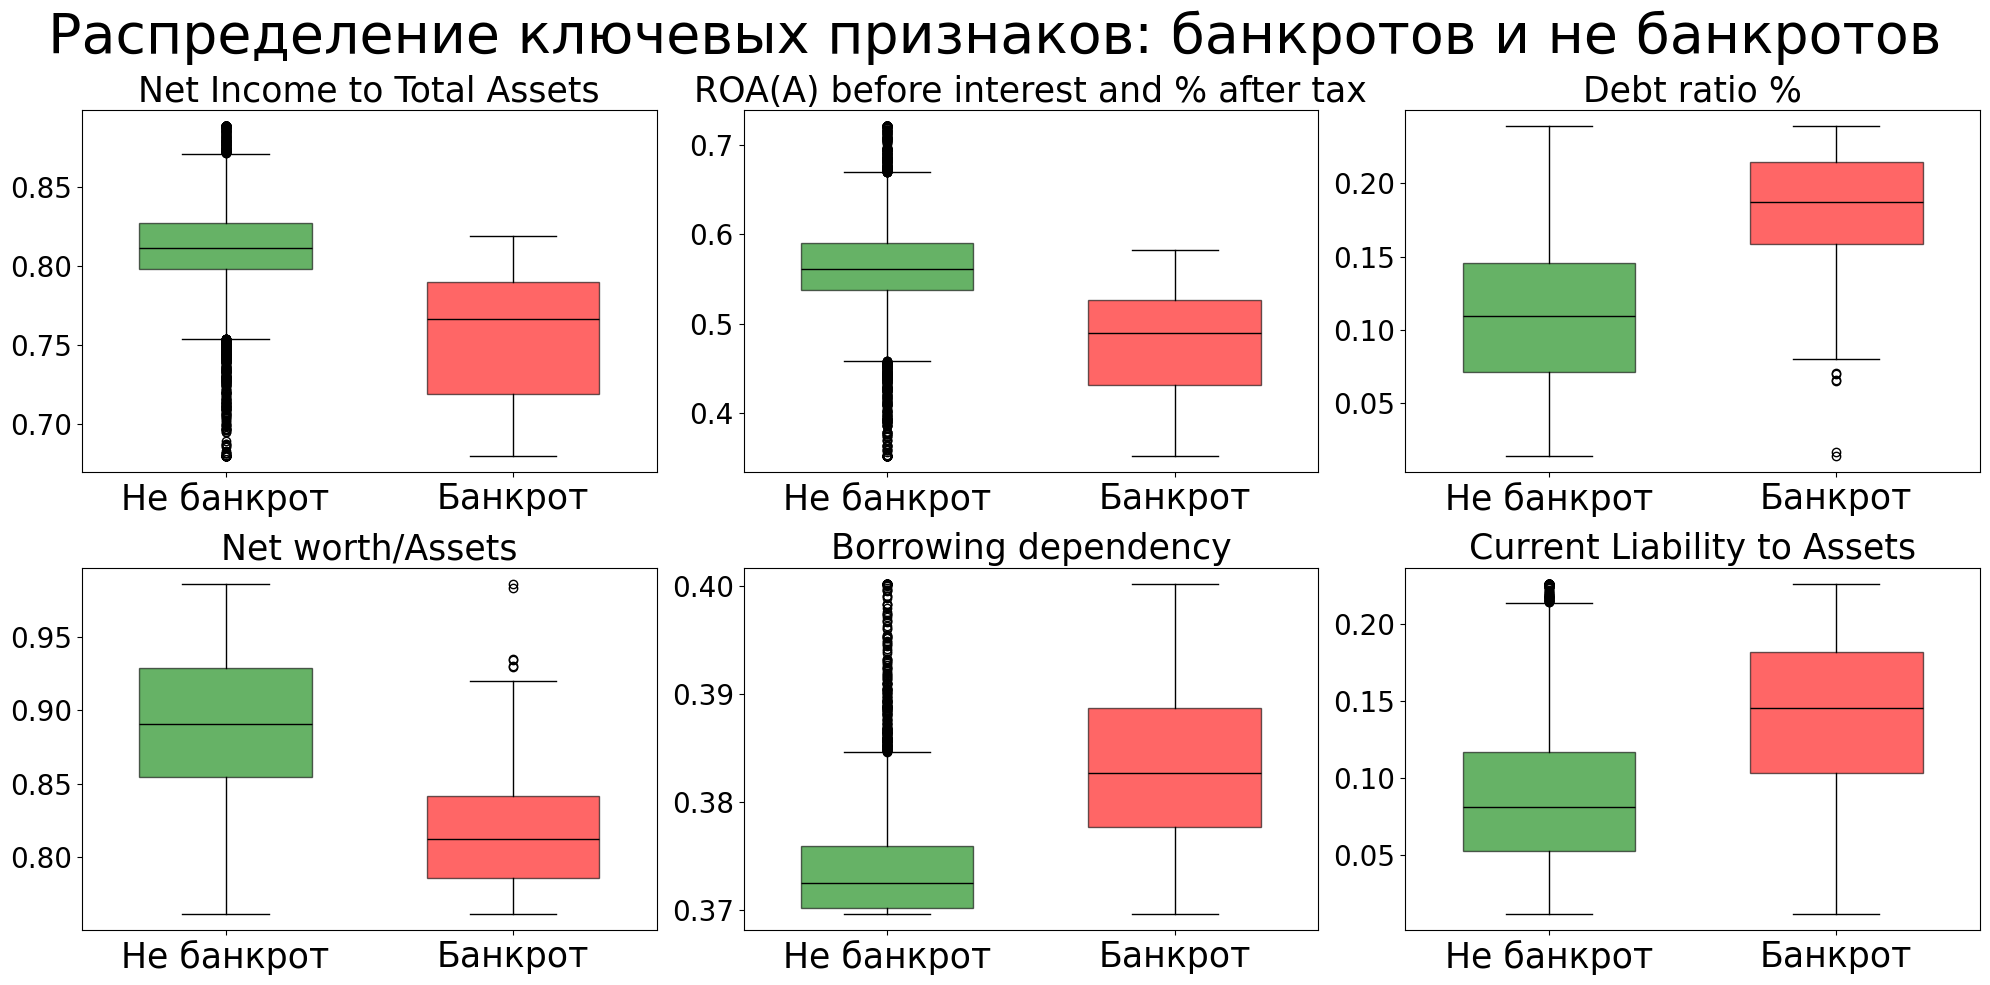

In [17]:
top6 = [
    'Net Income to Total Assets',
    'ROA(A) before interest and % after tax',
    'Debt ratio %',
    'Net worth/Assets',
    'Borrowing dependency',
    'Current Liability to Assets'
]

fig, axes = plt.subplots(2, 3, figsize=(20, 10))

for i, feat in enumerate(top6):
    ax = axes[i // 3][i % 3]
    cap_low = df_companies[feat].quantile(0.01)
    cap_high = df_companies[feat].quantile(0.99)
    data = df_companies[[feat, 'Bankrupt?']].copy()
    data[feat] = data[feat].clip(lower=cap_low, upper=cap_high)

    bp = ax.boxplot(
        [data[data['Bankrupt?'] == 0][feat],
         data[data['Bankrupt?'] == 1][feat]],
        patch_artist=True, widths=0.6,
        medianprops=dict(color='black')
    )
    bp['boxes'][0].set_facecolor('green')
    bp['boxes'][0].set_alpha(0.6)
    bp['boxes'][1].set_facecolor('red')
    bp['boxes'][1].set_alpha(0.6)

    ax.set_xticklabels(['Не банкрот', 'Банкрот'], fontsize=25)
    ax.set_title(feat, fontsize=25)
    ax.tick_params(axis='y', labelsize=20)

fig.suptitle('Распределение ключевых признаков: банкротов и не банкротов',
             fontsize=40)
plt.tight_layout()
plt.show()

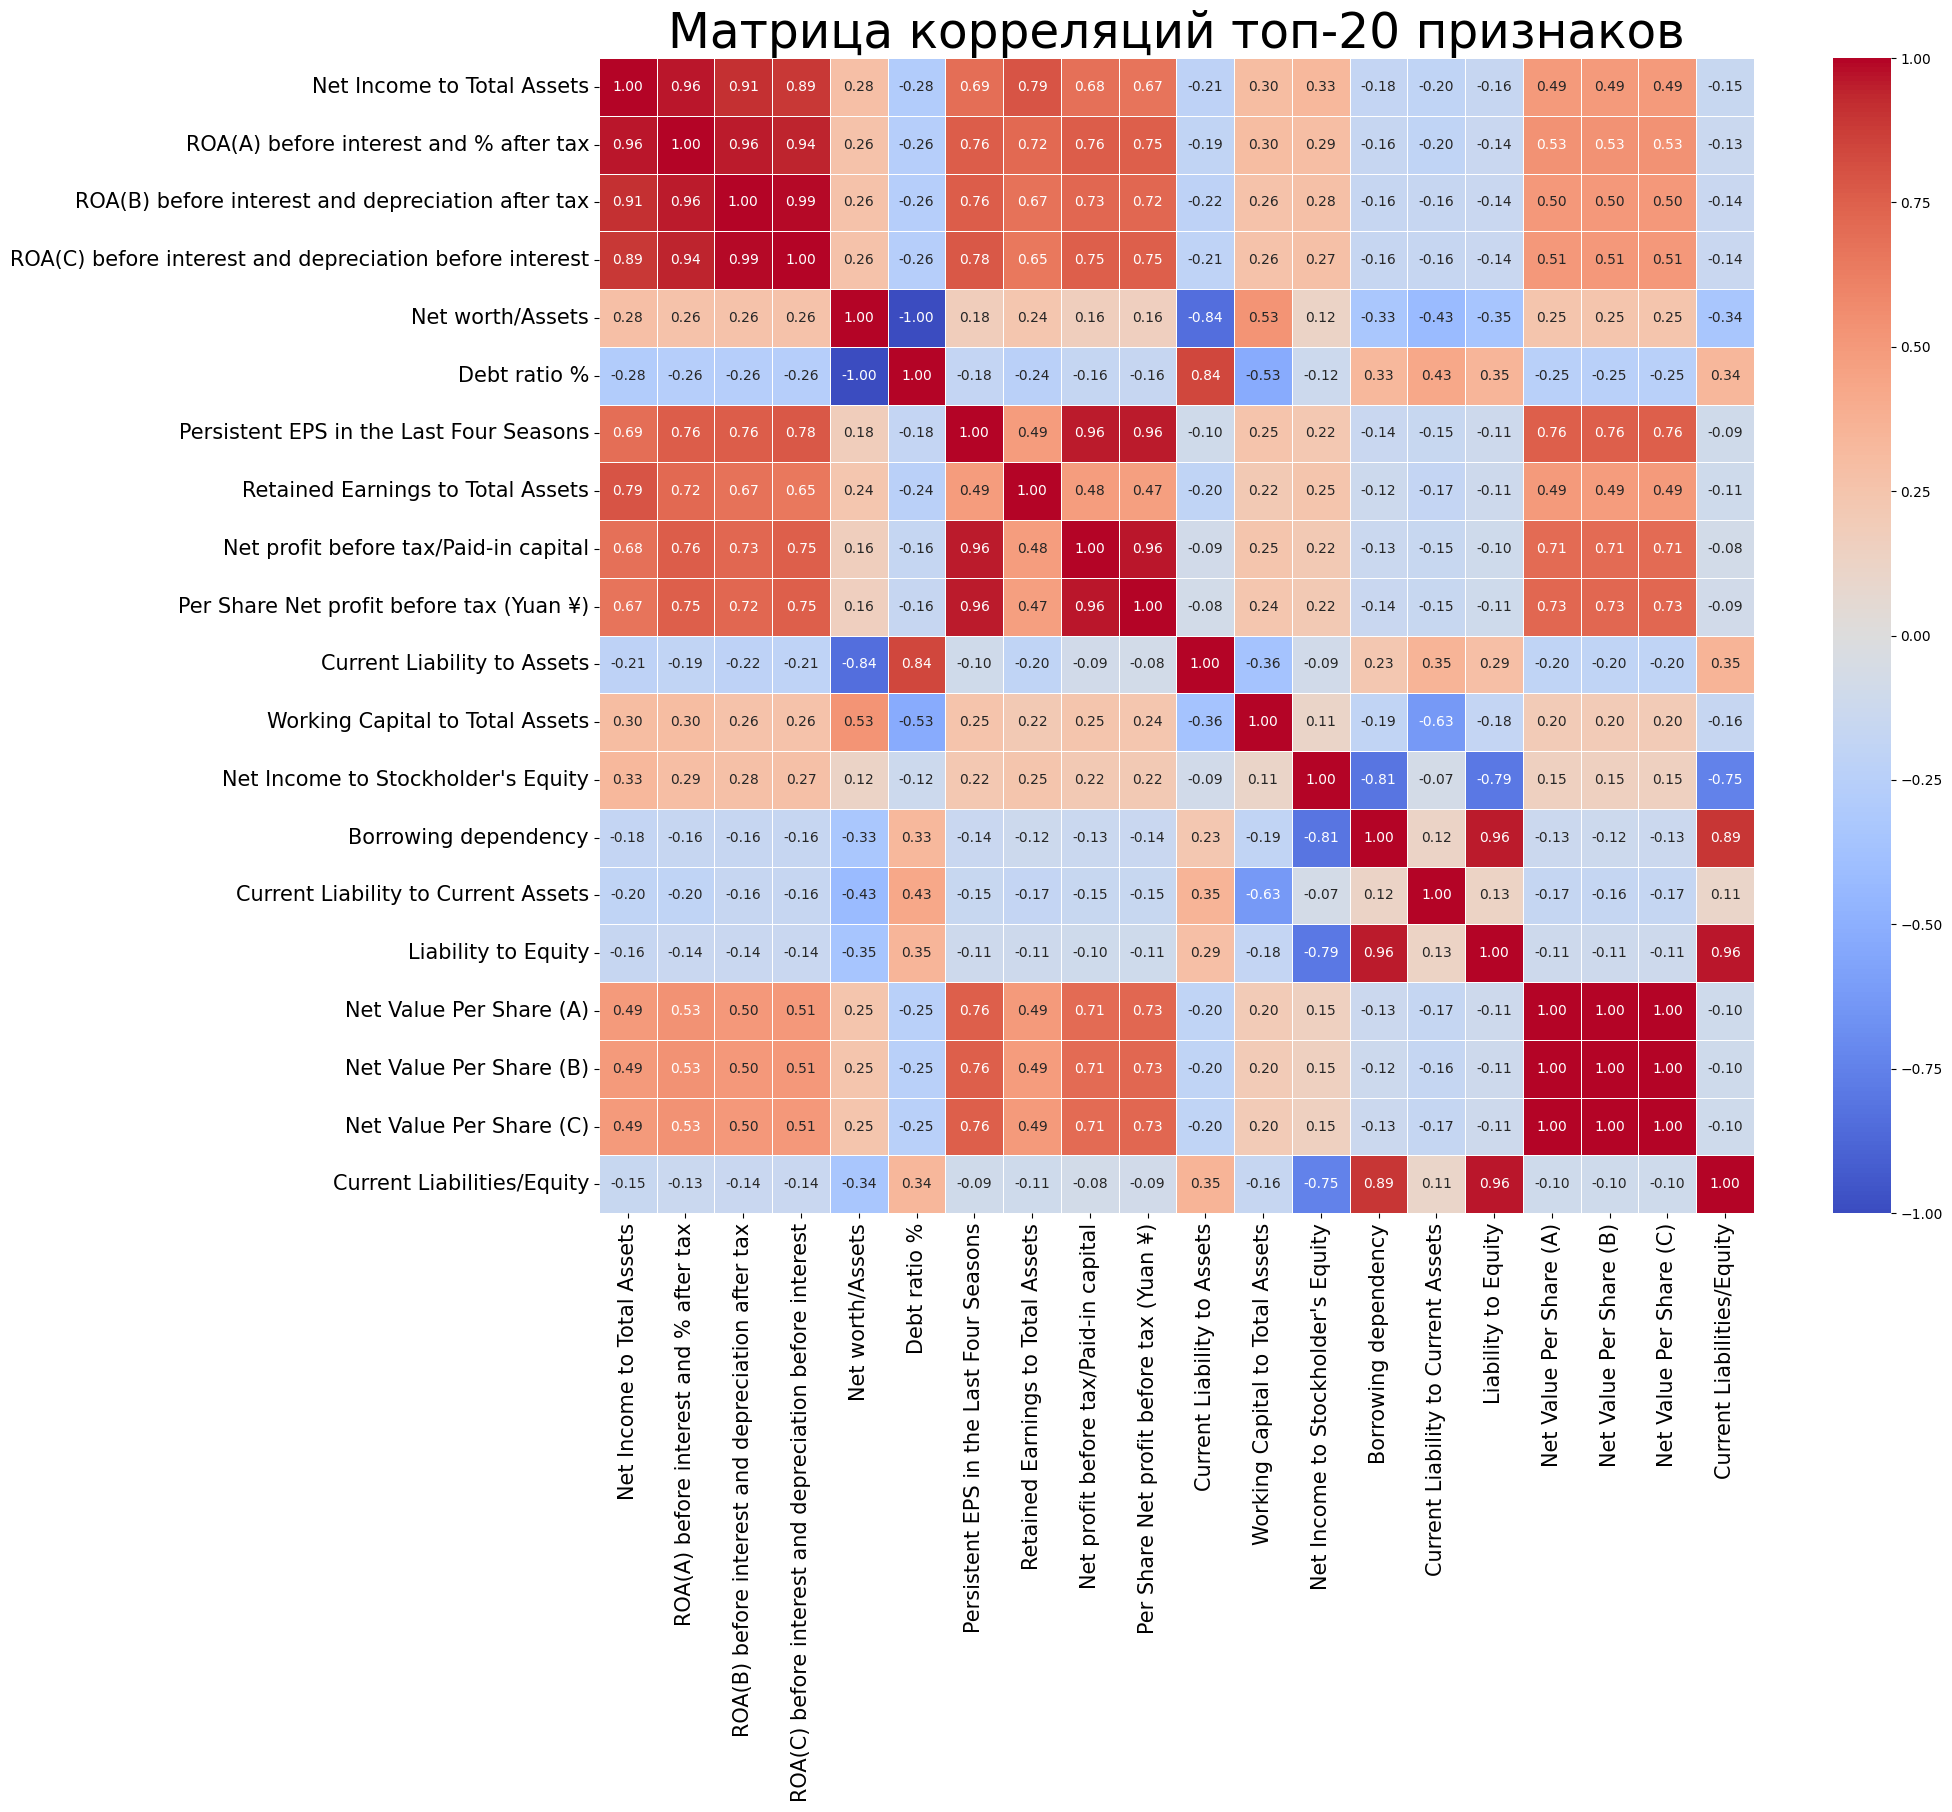

In [18]:
corr_top20 = df_companies[top20].corr()

plt.figure(figsize=(22, 18))

sns.heatmap(
    corr_top20,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    square=True,
    linewidths=0.5
)

plt.title('Матрица корреляций топ-20 признаков', fontsize=35)

plt.xticks(rotation=90, fontsize=15)
plt.yticks(fontsize=15)

plt.tight_layout()
plt.show()

Заметим, что присутствуют сильнокоррелированные экономические параметры. Некоторые вовсе повторяют другие. Удалим часть параметров.


In [19]:
corr_top20 = df_companies[top20].corr().abs()

upper = corr_top20.where(
    np.triu(np.ones(corr_top20.shape), k=1).astype(bool)
)

features_to_remove = [
    column for column in upper.columns
    if any(upper[column] > 0.9)
]

print('Удаляемые признаки:\n')

for feature in features_to_remove:
    print(feature)

final_features = [
    feature for feature in top20
    if feature not in features_to_remove
]

print('\nКоличество признаков после отбора:', len(final_features))

print('\nОставшиеся признаки:\n')

for feature in final_features:
    print(feature)


Удаляемые признаки:

ROA(A) before interest and % after tax
ROA(B) before interest and depreciation after tax
ROA(C) before interest and depreciation before interest
Debt ratio %
Net profit before tax/Paid-in capital
Per Share Net profit before tax (Yuan ¥)
Liability to Equity
Net Value Per Share (B)
Net Value Per Share (C)
Current Liabilities/Equity

Количество признаков после отбора: 10

Оставшиеся признаки:

Net Income to Total Assets
Net worth/Assets
Persistent EPS in the Last Four Seasons
Retained Earnings to Total Assets
Current Liability to Assets
Working Capital to Total Assets
Net Income to Stockholder's Equity
Borrowing dependency
Current Liability to Current Assets
Net Value Per Share (A)


Создадим новый датасет, в котором будут участвовать только отобранные экономические признаки

In [20]:

df_final = df_companies[final_features + ['Bankrupt?']]

#3. Подготвока данных

In [21]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = df_final.drop(columns=['Bankrupt?'])
y = df_final['Bankrupt?']

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2, random_state=111, stratify=y)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)




#4.Обучение моделей

##4.1 LogReg

In [22]:
from sklearn.linear_model import LogisticRegression

logreg = LogisticRegression(class_weight='balanced', max_iter=5000, random_state=111)

logreg.fit(X_train_scaled, y_train)

LogisticRegression(class_weight='balanced', max_iter=5000, random_state=111)

In [23]:
y_pred = logreg.predict(X_test_scaled)
y_proba = logreg.predict_proba(X_test_scaled)[:, 1]

In [24]:
from sklearn.metrics import (classification_report, confusion_matrix, roc_auc_score)

print(classification_report(y_test, y_pred))

print('ROC-AUC:', roc_auc_score(y_test, y_proba))

              precision    recall  f1-score   support

           0       1.00      0.86      0.92      1320
           1       0.17      0.91      0.29        44

    accuracy                           0.86      1364
   macro avg       0.58      0.88      0.61      1364
weighted avg       0.97      0.86      0.90      1364

ROC-AUC: 0.9367596418732782


##4.2 XGBoost

In [25]:
from xgboost import XGBClassifier

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

xgb = XGBClassifier(n_estimators=100, scale_pos_weight=scale_pos_weight, random_state=111, eval_metric='logloss')
xgb.fit(X_train_scaled, y_train)

y_pred_xgb = xgb.predict(X_test_scaled)
y_proba_xgb = xgb.predict_proba(X_test_scaled)[:, 1]

print(classification_report(y_test, y_pred_xgb))
print('ROC-AUC:', roc_auc_score(y_test, y_proba_xgb))

              precision    recall  f1-score   support

           0       0.98      0.98      0.98      1320
           1       0.30      0.32      0.31        44

    accuracy                           0.95      1364
   macro avg       0.64      0.65      0.64      1364
weighted avg       0.96      0.95      0.96      1364

ROC-AUC: 0.9200241046831956


##4.3 Random Forest

In [26]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=111)
rf.fit(X_train_scaled, y_train)

y_pred_rf = rf.predict(X_test_scaled)
y_proba_rf = rf.predict_proba(X_test_scaled)[:, 1]

print(classification_report(y_test, y_pred_rf))
print('ROC-AUC:', roc_auc_score(y_test, y_proba_rf))

              precision    recall  f1-score   support

           0       0.97      1.00      0.99      1320
           1       0.80      0.18      0.30        44

    accuracy                           0.97      1364
   macro avg       0.89      0.59      0.64      1364
weighted avg       0.97      0.97      0.96      1364

ROC-AUC: 0.9168818870523414


#5. Сравнение моделей


In [27]:
from sklearn.metrics import f1_score, precision_score, recall_score

models = {'Logistic Regression':(y_pred, y_proba), 'Random Forest':(y_pred_rf, y_proba_rf), 'XGBoost':(y_pred_xgb, y_proba_xgb)}

results = {}
for name, (pred, proba) in models.items():
    results[name] = {
        'ROC-AUC':  roc_auc_score(y_test, proba),
        'F1':       f1_score(y_test, pred),
        'Precision': precision_score(y_test, pred),
        'Recall':   recall_score(y_test, pred),
    }

df_results = pd.DataFrame(results).T
print(df_results.round(3))

                     ROC-AUC     F1  Precision  Recall
Logistic Regression    0.937  0.291      0.173   0.909
Random Forest          0.917  0.296      0.800   0.182
XGBoost                0.920  0.311      0.304   0.318


Визуализируем сравнение моделей

/tmp/ipykernel_3220/511367782.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(df_results.index, rotation=45, ha='right', fontsize=15)
/tmp/ipykernel_3220/511367782.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(df_results.index, rotation=45, ha='right', fontsize=15)
/tmp/ipykernel_3220/511367782.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(df_results.index, rotation=45, ha='right', fontsize=15)
/tmp/ipykernel_3220/511367782.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(df_results.index, rotation=45, ha='right', fontsize=15)


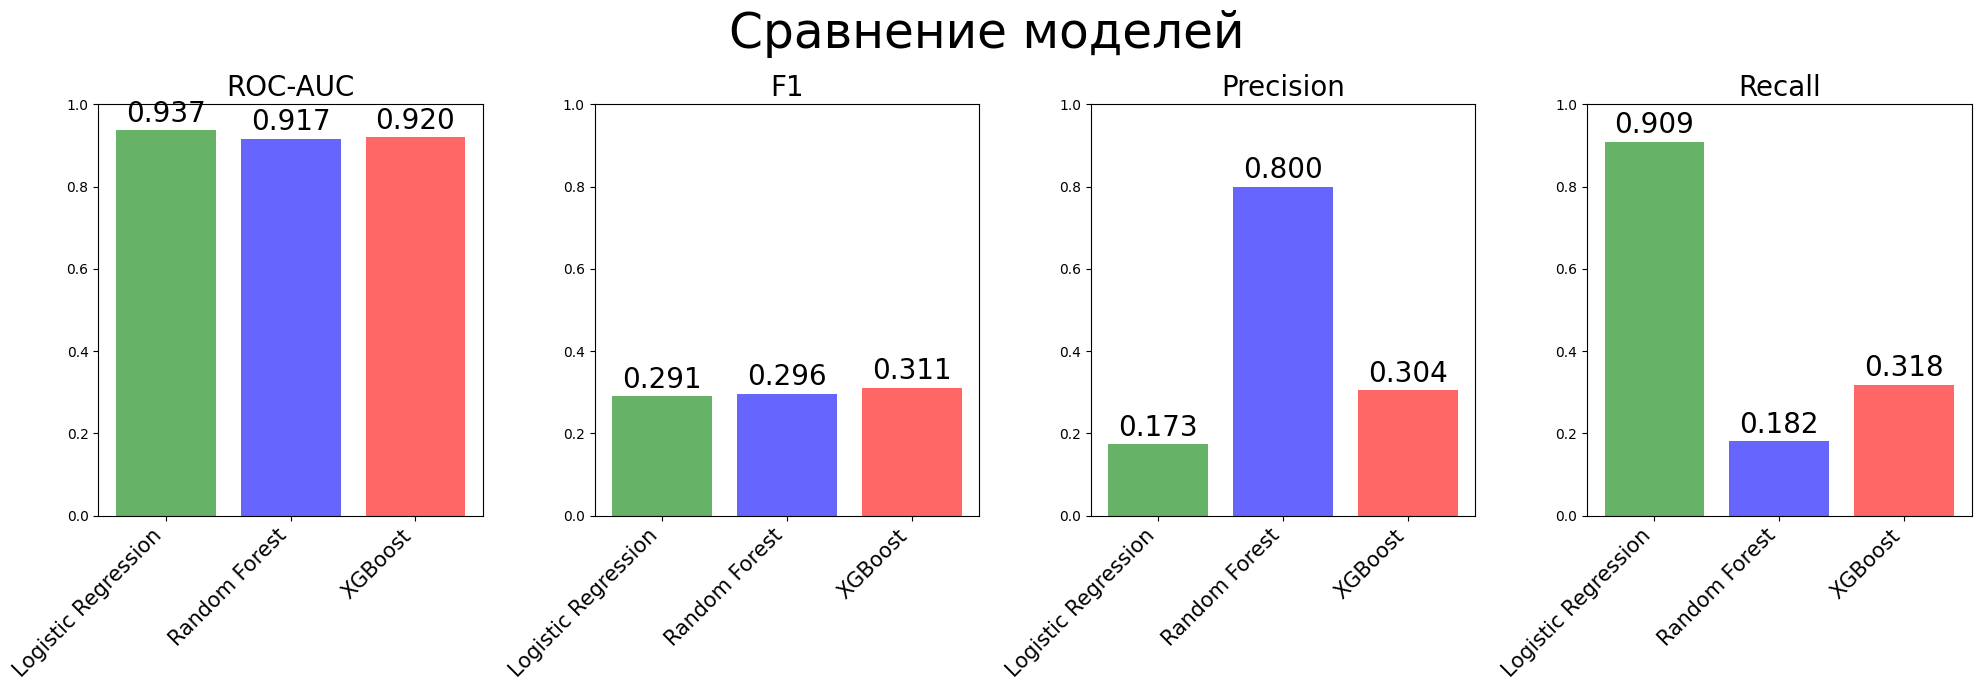

In [28]:

fig, axes = plt.subplots(1, 4, figsize=(20, 7))
metrics = ['ROC-AUC', 'F1', 'Precision', 'Recall']
colors = ['green', 'blue', 'red']

for ax, metric in zip(axes, metrics):
    bars = ax.bar(df_results.index, df_results[metric], color=colors, alpha=0.6)
    ax.set_title(metric, fontsize=20)
    ax.set_ylim(0, 1)
    ax.set_xticklabels(df_results.index, rotation=45, ha='right', fontsize=15)
    ax.tick_params(axis='y', labelsize=10)
    for bar, val in zip(bars, df_results[metric]):
        ax.text(bar.get_x() + bar.get_width() / 2,
                val + 0.02, f'{val:.3f}',
                ha='center', fontsize=20)

fig.suptitle('Сравнение моделей', fontsize=35)
plt.tight_layout()
plt.show()

Визуализируем ROC-кривые

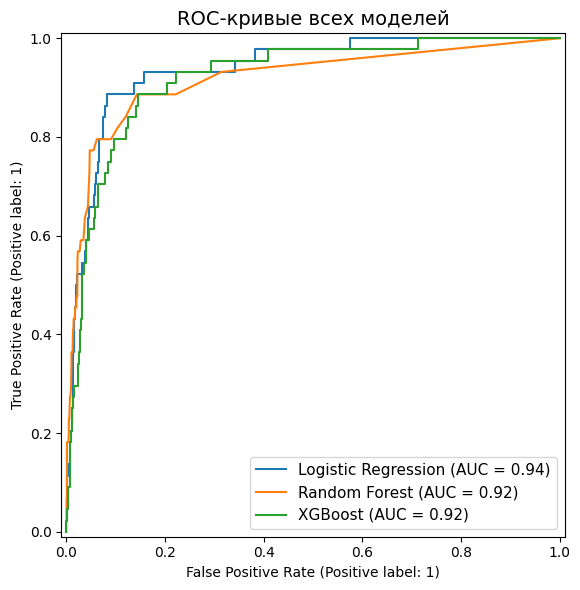

In [29]:

from sklearn.metrics import RocCurveDisplay

fig, ax = plt.subplots(figsize=(8, 6))

for name, (pred, proba) in models.items():
    RocCurveDisplay.from_predictions(y_test, proba, ax=ax, name=name)

ax.set_title('ROC-кривые всех моделей', fontsize=14)
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

###Ключевые вывод из сравнения моделей:

1. Лучше всего себя показала логистическая регрессия:
- она имеет лучшую ROC - кривую
- ее Recall = 0.91. Такой показатель является безооговрочным лидером.
Однако эта модель имеет очень низкий Precision. Т.е. модель на каждого реального банкрота помечает около 5 здоровых компаний

2. Лучшей по балансу является модель XGBoost, которая имеет $F_1$=0.31, но этот показатель не сильно выше других.
При этом эта модель имеет, как низки Precision, так и низкий Recall

3. Random Forest выделяется своим высоким Precision, но эток компенсируется очень низким Recall'ом, что плохо(

Такие показатели однозначно являются следствием дизбаланса классов.

ROC-кривые у всех моделей сравнительно хороши, что говорит о способности моделей расставить компании по вероятности банкротства.

#6. Важность признаков (опираясь на Random Forest)

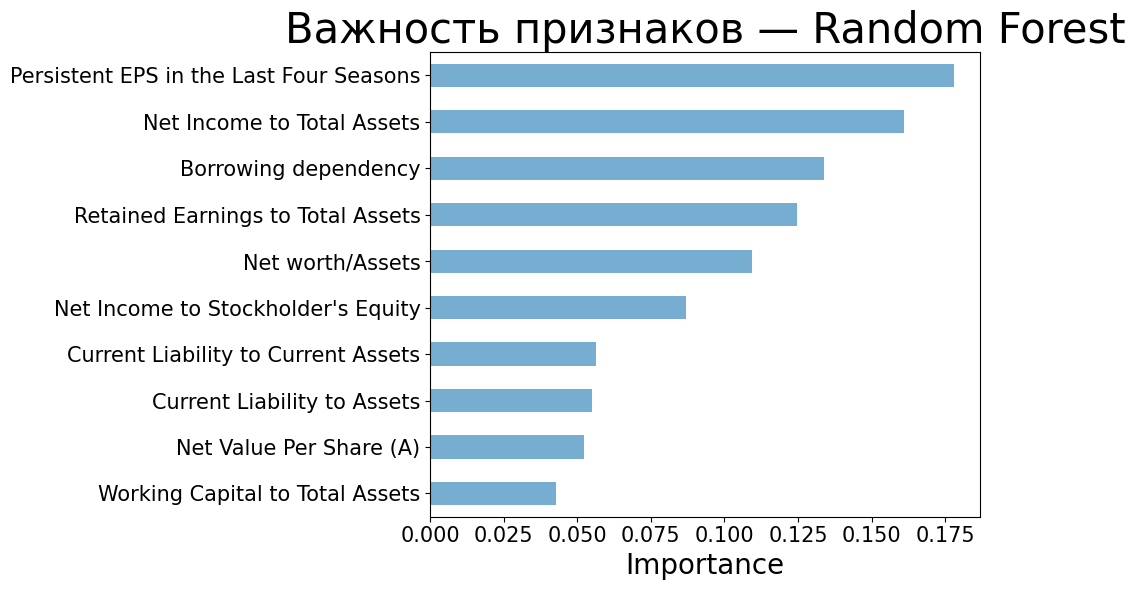

In [30]:

feat_imp = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=True)

plt.figure(figsize=(10, 6))
feat_imp.plot(kind='barh', alpha=0.6)
plt.title('Важность признаков — Random Forest', fontsize=30)
plt.xlabel('Importance', fontsize=20)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.tight_layout()
plt.show()

Заметим, что ключевыми признаками, влиящими на банкротство, являются:
- стабильность прибыли на последние 4 квартала
- рентабельность активов
- зависимость от кредитных денег
что вполне укладывается в рамки разумного.


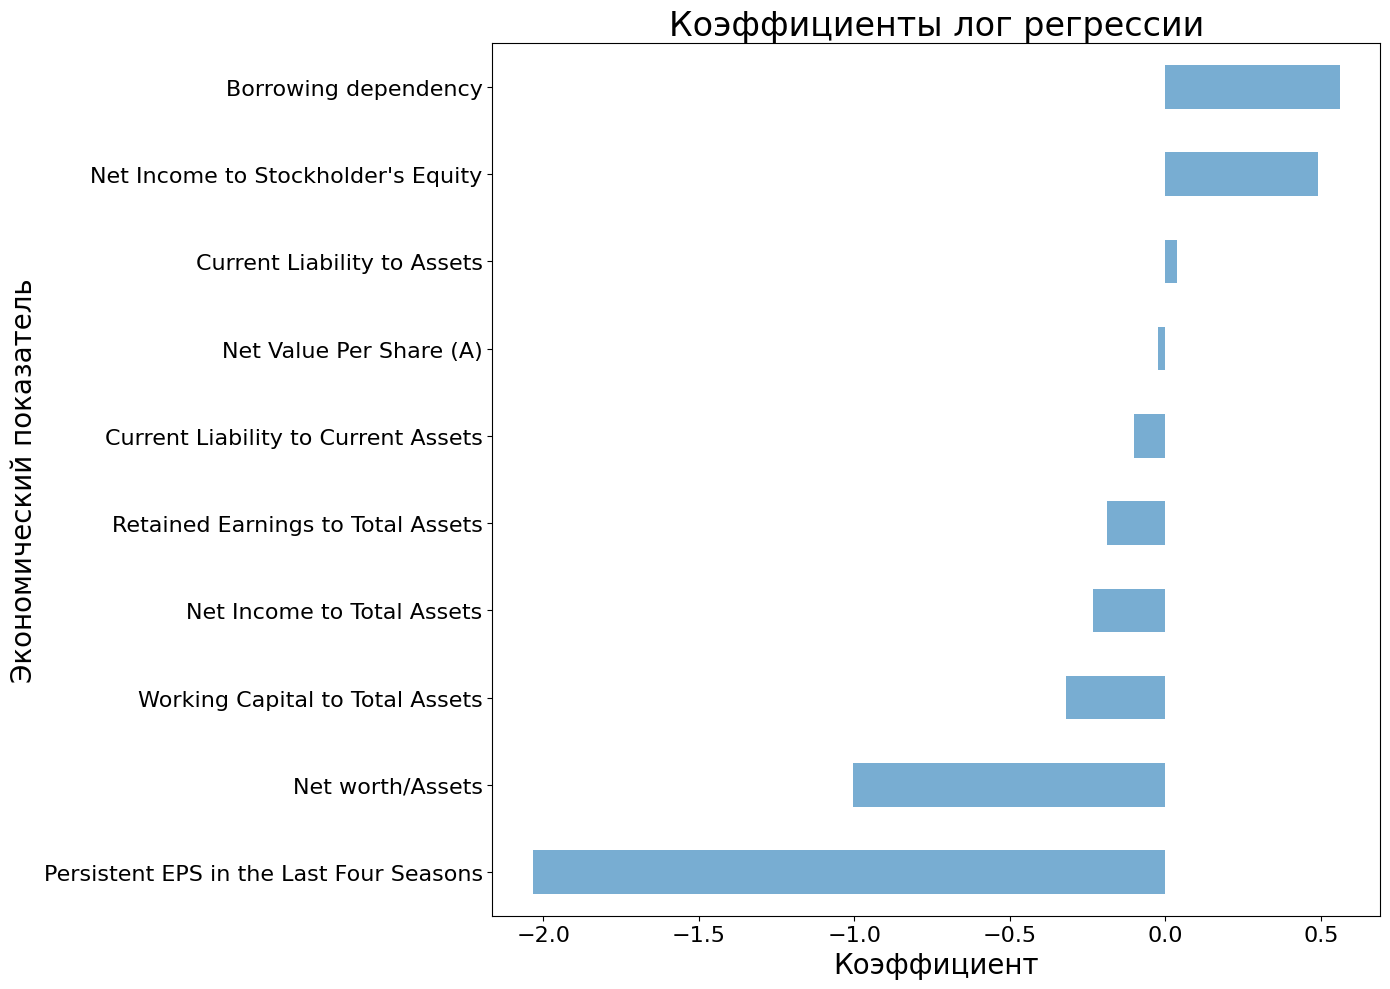

In [31]:
coef_df = pd.DataFrame({'Feature': X.columns, 'Coefficient': logreg.coef_[0]})

coef_df = coef_df.sort_values(by='Coefficient')

ax = coef_df.plot(x='Feature',y='Coefficient', kind='barh', figsize=(14,10), legend=False, fontsize=16, alpha=0.6)

ax.set_title('Коэффициенты лог регрессии', fontsize=24)

ax.set_xlabel('Коэффициент', fontsize=20)

ax.set_ylabel('Экономический показатель',fontsize=20)

ax.tick_params(axis='x', labelsize=16)
ax.tick_params(axis='y', labelsize=16)

plt.tight_layout()
plt.show()

По коэффициента лог регрессии видно, что ключевые признаки совпадают с признаками Random Forest.
При этом чем лучше показатель Persistent EPS in the Last Four Seasons, тем меньше вероятность стать банкротом, что вполне укладывается в разумное представление


#7. Итоги

- Ключевая проблема датасета - дизбаланс классов. Из-за него ни одна модель не набрала $F_1$ больше 0.31

- Лучшей моделью стала логистическая регрессия

- Ключевые экономические показатели, которые влияют на банкротство: Persistent EPS in the Last Four Seasons, Net Income to Total Assets, Borrowing dependency



#8. Отбор гиперпараметров

Проблема: предыдущее исследование показало достаточно странные результаты: у всех моделей достаточно низкий $F_1$, при этом он идентичен.

Попробуем сделать отбор гиперпараметров для различных моделей.

При этом, используя гридсерч, будем оптимизировать $F_1-score$

##8.1 LogReg

In [32]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score, f1_score, precision_score, recall_score

In [33]:
param_grid_lr = {
    'C': [0.01, 0.1, 1, 10, 100, 1000],
    'solver': ['lbfgs', 'liblinear', 'saga'],
}

gs_lr = GridSearchCV(
    LogisticRegression(class_weight='balanced', max_iter=5000, random_state=111),
    param_grid_lr,
    cv=5,
    scoring='f1',
    n_jobs=-1
)
gs_lr.fit(X_train_scaled, y_train)

print('Лучшие параметры LogReg:', gs_lr.best_params_)
print('Лучший F1:', gs_lr.best_score_.round(3))

y_pred_lr_gs = gs_lr.predict(X_test_scaled)
y_proba_lr_gs = gs_lr.predict_proba(X_test_scaled)[:, 1]
print(classification_report(y_test, y_pred_lr_gs))
print('ROC-AUC:', roc_auc_score(y_test, y_proba_lr_gs).round(3))

Лучшие параметры LogReg: {'C': 0.01, 'solver': 'lbfgs'}
Лучший F1: 0.279
              precision    recall  f1-score   support

           0       1.00      0.85      0.92      1320
           1       0.17      0.91      0.29        44

    accuracy                           0.85      1364
   macro avg       0.58      0.88      0.60      1364
weighted avg       0.97      0.85      0.90      1364

ROC-AUC: 0.936


##8.2 Random Forest

In [34]:
param_grid_rf = {
    'n_estimators': [100, 200, 500, 1000],
    'max_depth': [10, 25, 50, None],
    'min_samples_leaf': [1, 2, 5]
}

gs_rf = GridSearchCV(
    RandomForestClassifier(class_weight='balanced', random_state=111),
    param_grid_rf,
    cv=5,
    scoring='f1',
    n_jobs=-1
)
gs_rf.fit(X_train_scaled, y_train)

print('Лучшие параметры Random Forest:', gs_rf.best_params_)
print('Лучший F1', gs_rf.best_score_.round(3))

y_pred_rf_gs = gs_rf.predict(X_test_scaled)
y_proba_rf_gs = gs_rf.predict_proba(X_test_scaled)[:, 1]
print(classification_report(y_test, y_pred_rf_gs))
print('ROC-AUC:', roc_auc_score(y_test, y_proba_rf_gs).round(3))

Лучшие параметры Random Forest: {'max_depth': 10, 'min_samples_leaf': 5, 'n_estimators': 100}
Лучший F1 0.421
              precision    recall  f1-score   support

           0       0.99      0.97      0.98      1320
           1       0.38      0.61      0.47        44

    accuracy                           0.95      1364
   macro avg       0.68      0.79      0.72      1364
weighted avg       0.97      0.95      0.96      1364

ROC-AUC: 0.934


##8.3 XGBoost


In [41]:
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

param_grid_xgb = {
    'n_estimators': [100, 200, 500, 1000],
    'max_depth': [10, 20, None],
    'learning_rate': [0.001, 0.01, 0.1, 0.3],
}

gs_xgb = GridSearchCV(
    XGBClassifier(scale_pos_weight=scale_pos_weight, random_state=111, eval_metric='logloss'),
    param_grid_xgb,
    cv=5,
    scoring='f1',
    n_jobs=-1
)
gs_xgb.fit(X_train_scaled, y_train)

print('Лучшие параметры XGBoost:', gs_xgb.best_params_)
print('Лучший F1:', gs_xgb.best_score_.round(3))

y_pred_xgb_gs = gs_xgb.predict(X_test_scaled)
y_proba_xgb_gs = gs_xgb.predict_proba(X_test_scaled)[:, 1]
print(classification_report(y_test, y_pred_xgb_gs))
print('ROC-AUC:', roc_auc_score(y_test, y_proba_xgb_gs).round(3))

Лучшие параметры XGBoost: {'learning_rate': 0.01, 'max_depth': None, 'n_estimators': 1000}
Лучший F1: 0.361
              precision    recall  f1-score   support

           0       0.99      0.96      0.97      1320
           1       0.32      0.59      0.42        44

    accuracy                           0.95      1364
   macro avg       0.65      0.77      0.69      1364
weighted avg       0.96      0.95      0.95      1364

ROC-AUC: 0.931


#9. Сравнение показателей после гридсерча


In [45]:
results_comparison = {
    'LogReg (до)':        (y_pred,        y_proba),
    'LogReg (GridSearch)': (y_pred_lr_gs, y_proba_lr_gs),
    'RF (до)':            (y_pred_rf,     y_proba_rf),
    'RF (GridSearch)':    (y_pred_rf_gs,  y_proba_rf_gs),
    'XGBoost (до)':       (y_pred_xgb,    y_proba_xgb),
    'XGBoost (GridSearch)':(y_pred_xgb_gs,y_proba_xgb_gs),
}

rows = {}
for name, (pred, proba) in results_comparison.items():
    rows[name] = {
        'ROC-AUC':  round(roc_auc_score(y_test, proba), 3),
        'F1':       round(f1_score(y_test, pred), 3),
        'Precision': round(precision_score(y_test, pred), 3),
        'Recall':   round(recall_score(y_test, pred), 3),
    }

df_comparison = pd.DataFrame(rows).T
print(df_comparison)

                      ROC-AUC     F1  Precision  Recall
LogReg (до)             0.937  0.291      0.173   0.909
LogReg (GridSearch)     0.936  0.287      0.170   0.909
RF (до)                 0.917  0.296      0.800   0.182
RF (GridSearch)         0.934  0.466      0.375   0.614
XGBoost (до)            0.920  0.311      0.304   0.318
XGBoost (GridSearch)    0.931  0.416      0.321   0.591


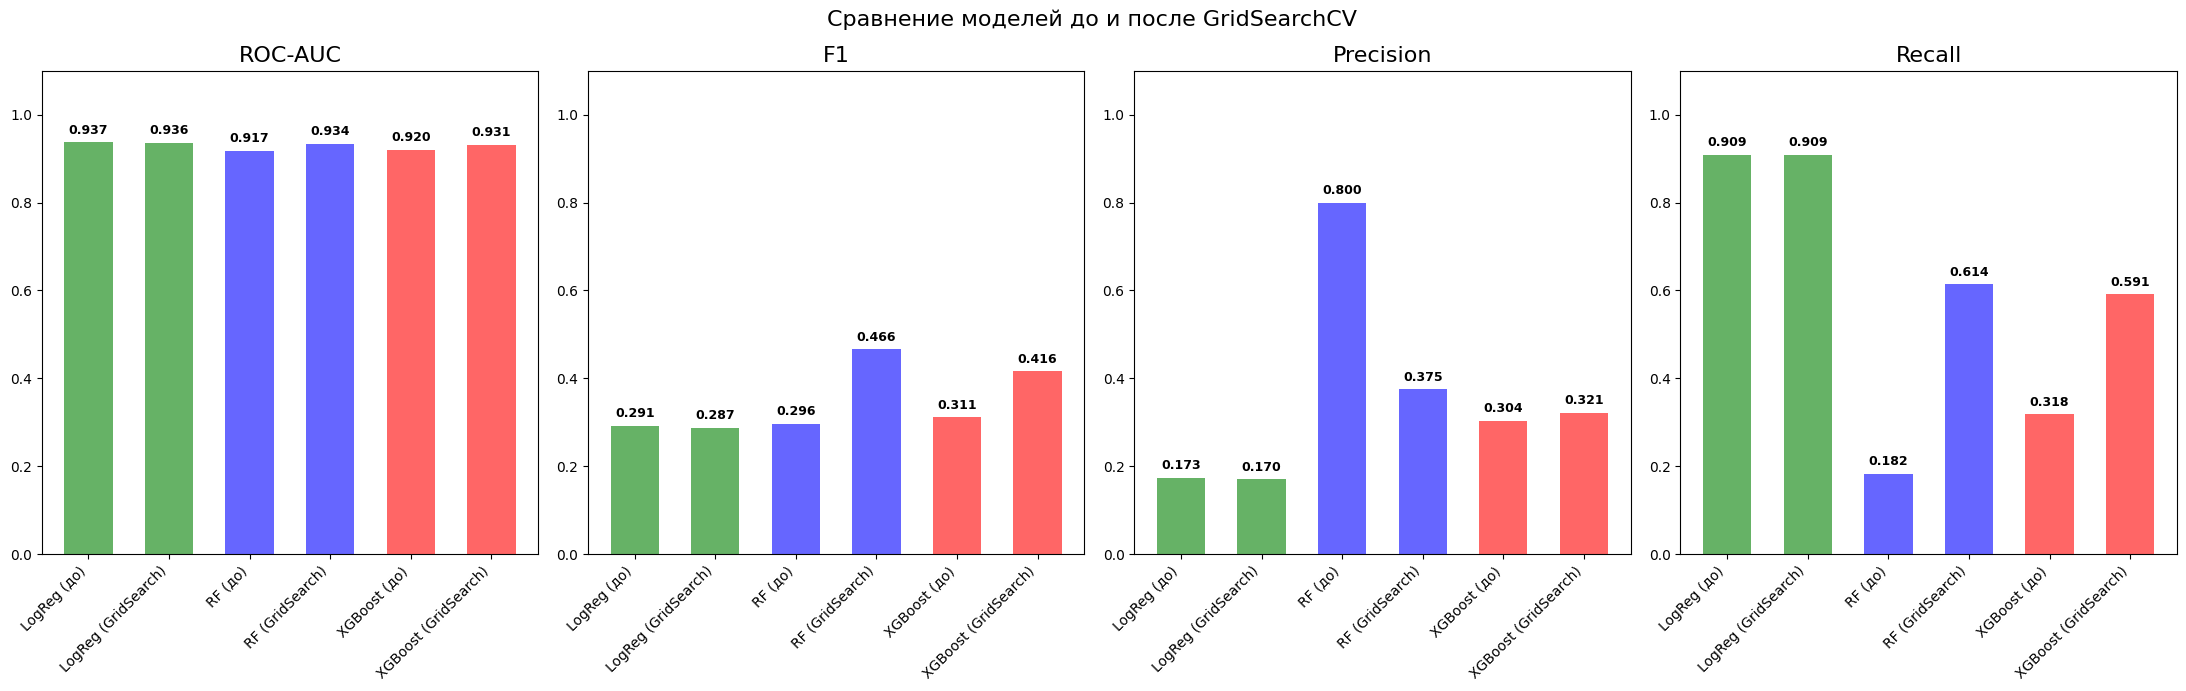

In [46]:
fig, axes = plt.subplots(1, 4, figsize=(22, 7))
metrics = ['ROC-AUC', 'F1', 'Precision', 'Recall']
colors = ['green', 'green', 'blue', 'blue', 'red', 'red']

for ax, metric in zip(axes, metrics):
    bars = ax.bar(range(len(df_comparison)), df_comparison[metric],
                  color=colors, alpha=0.6, width=0.6)
    ax.set_title(metric, fontsize=16)
    ax.set_ylim(0, 1.1)
    ax.set_xticks(range(len(df_comparison)))
    ax.set_xticklabels(df_comparison.index, rotation=45, ha='right', fontsize=10)
    ax.tick_params(axis='y', labelsize=10)
    for bar, val in zip(bars, df_comparison[metric]):
        ax.text(bar.get_x() + bar.get_width()/2,
                val + 0.02, f'{val:.3f}',
                ha='center', fontsize=9, fontweight='bold')

fig.suptitle('Сравнение моделей до и после GridSearchCV', fontsize=16)
plt.tight_layout()
plt.show()

Интересным кажется, что только XGBoost показал улучшение по всем метрикам после гридсерча. Случайный лес полностью перестроился и стал показывать лучший $F_1$, при этом пресижн сильно упал. Интересно, что Recall самый лучший все еще у логрег.

#10. Отбор гиперпараметров (2)
сделаем отбор для увеличения recall

In [47]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import classification_report, roc_auc_score, f1_score, precision_score, recall_score
from sklearn.metrics import make_scorer

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=111)

recall_scorer = make_scorer(recall_score, pos_label=1)

In [48]:
param_grid_lr_recall = {
    'C': [0.01, 0.1, 1, 10, 100],
    'solver': ['lbfgs', 'liblinear'],
    'class_weight': [
        'balanced',
        {0: 1, 1: 5},
        {0: 1, 1: 10},
        {0: 1, 1: 20},
        {0: 1, 1: 30}
    ]
}

gs_lr_recall = GridSearchCV(
    LogisticRegression(max_iter=5000, random_state=111),
    param_grid_lr_recall,
    cv=cv,
    scoring=recall_scorer,
    n_jobs=-1
)

gs_lr_recall.fit(X_train_scaled, y_train)

print('Лучшие параметры LogReg для Recall:', gs_lr_recall.best_params_)
print('Лучший Recall на CV:', round(gs_lr_recall.best_score_, 3))

y_pred_lr_recall = gs_lr_recall.predict(X_test_scaled)
y_proba_lr_recall = gs_lr_recall.predict_proba(X_test_scaled)[:, 1]

print(classification_report(y_test, y_pred_lr_recall))
print('ROC-AUC:', round(roc_auc_score(y_test, y_proba_lr_recall), 3))

Лучшие параметры LogReg для Recall: {'C': 0.01, 'class_weight': 'balanced', 'solver': 'liblinear'}
Лучший Recall на CV: 0.875
              precision    recall  f1-score   support

           0       1.00      0.83      0.90      1320
           1       0.15      0.91      0.25        44

    accuracy                           0.83      1364
   macro avg       0.57      0.87      0.58      1364
weighted avg       0.97      0.83      0.88      1364

ROC-AUC: 0.937


In [49]:
param_grid_rf_recall = {
    'n_estimators': [100, 200, 500],
    'max_depth': [5, 10, 25, None],
    'min_samples_leaf': [1, 2, 5],
    'class_weight': [
        'balanced',
        'balanced_subsample',
        {0: 1, 1: 5},
        {0: 1, 1: 10},
        {0: 1, 1: 20}
    ]
}

gs_rf_recall = GridSearchCV(
    RandomForestClassifier(random_state=111),
    param_grid_rf_recall,
    cv=cv,
    scoring=recall_scorer,
    n_jobs=-1
)

gs_rf_recall.fit(X_train, y_train)

print('Лучшие параметры Random Forest для Recall:', gs_rf_recall.best_params_)
print('Лучший Recall на CV:', round(gs_rf_recall.best_score_, 3))

y_pred_rf_recall = gs_rf_recall.predict(X_test)
y_proba_rf_recall = gs_rf_recall.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred_rf_recall))
print('ROC-AUC:', round(roc_auc_score(y_test, y_proba_rf_recall), 3))

Лучшие параметры Random Forest для Recall: {'class_weight': 'balanced', 'max_depth': 5, 'min_samples_leaf': 5, 'n_estimators': 100}
Лучший Recall на CV: 0.75
              precision    recall  f1-score   support

           0       1.00      0.92      0.95      1320
           1       0.26      0.89      0.40        44

    accuracy                           0.92      1364
   macro avg       0.63      0.90      0.68      1364
weighted avg       0.97      0.92      0.94      1364

ROC-AUC: 0.937


In [50]:
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

param_grid_xgb_recall = {
    'n_estimators': [100, 200, 500],
    'max_depth': [3, 5, 7, 10],
    'learning_rate': [0.01, 0.05, 0.1],
    'scale_pos_weight': [
        scale_pos_weight,
        scale_pos_weight * 2,
        scale_pos_weight * 3
    ]
}

gs_xgb_recall = GridSearchCV(
    XGBClassifier(
        random_state=111,
        eval_metric='logloss'
    ),
    param_grid_xgb_recall,
    cv=cv,
    scoring=recall_scorer,
    n_jobs=-1
)

gs_xgb_recall.fit(X_train, y_train)

print('Лучшие параметры XGBoost для Recall:', gs_xgb_recall.best_params_)
print('Лучший Recall на CV:', round(gs_xgb_recall.best_score_, 3))

y_pred_xgb_recall = gs_xgb_recall.predict(X_test)
y_proba_xgb_recall = gs_xgb_recall.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred_xgb_recall))
print('ROC-AUC:', round(roc_auc_score(y_test, y_proba_xgb_recall), 3))

Лучшие параметры XGBoost для Recall: {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 100, 'scale_pos_weight': np.float64(89.98295454545455)}
Лучший Recall на CV: 0.943
              precision    recall  f1-score   support

           0       1.00      0.68      0.81      1320
           1       0.09      0.95      0.16        44

    accuracy                           0.69      1364
   macro avg       0.54      0.82      0.49      1364
weighted avg       0.97      0.69      0.79      1364

ROC-AUC: 0.929


In [60]:


results_comparison_3 = {
    'LogReg (до)':              (y_pred, y_proba),
    'LogReg (GS F1)':   (y_pred_lr_gs, y_proba_lr_gs),
    'LogReg (GS Recall)': (y_pred_lr_recall, y_proba_lr_recall),

    'RF (до)':                  (y_pred_rf, y_proba_rf),
    'RF (GS F1)':       (y_pred_rf_gs, y_proba_rf_gs),
    'RF (GS Recall)':   (y_pred_rf_recall, y_proba_rf_recall),

    'XGBoost (до)':             (y_pred_xgb, y_proba_xgb),
    'XGBoost (GS F1)':  (y_pred_xgb_gs, y_proba_xgb_gs),
    'XGBoost (GS Recall)': (y_pred_xgb_recall, y_proba_xgb_recall),
}

rows = {}

for name, (pred, proba) in results_comparison_3.items():
    rows[name] = {
        'ROC-AUC': round(roc_auc_score(y_test, proba), 3),
        'F1': round(f1_score(y_test, pred), 3),
        'Precision': round(precision_score(y_test, pred), 3),
        'Recall': round(recall_score(y_test, pred), 3),
    }

df_comparison_3 = pd.DataFrame(rows).T

df_comparison_3

,ROC-AUC,F1,Precision,Recall
LogReg (до),0.937,0.291,0.173,0.909
LogReg (GS F1),0.936,0.287,0.170,0.909
LogReg (GS Recall),0.937,0.255,0.148,0.909
RF (до),0.917,0.296,0.800,0.182
RF (GS F1),0.934,0.466,0.375,0.614
RF (GS Recall),0.937,0.404,0.262,0.886
XGBoost (до),0.920,0.311,0.304,0.318
XGBoost (GS F1),0.931,0.416,0.321,0.591
XGBoost (GS Recall),0.929,0.164,0.090,0.955


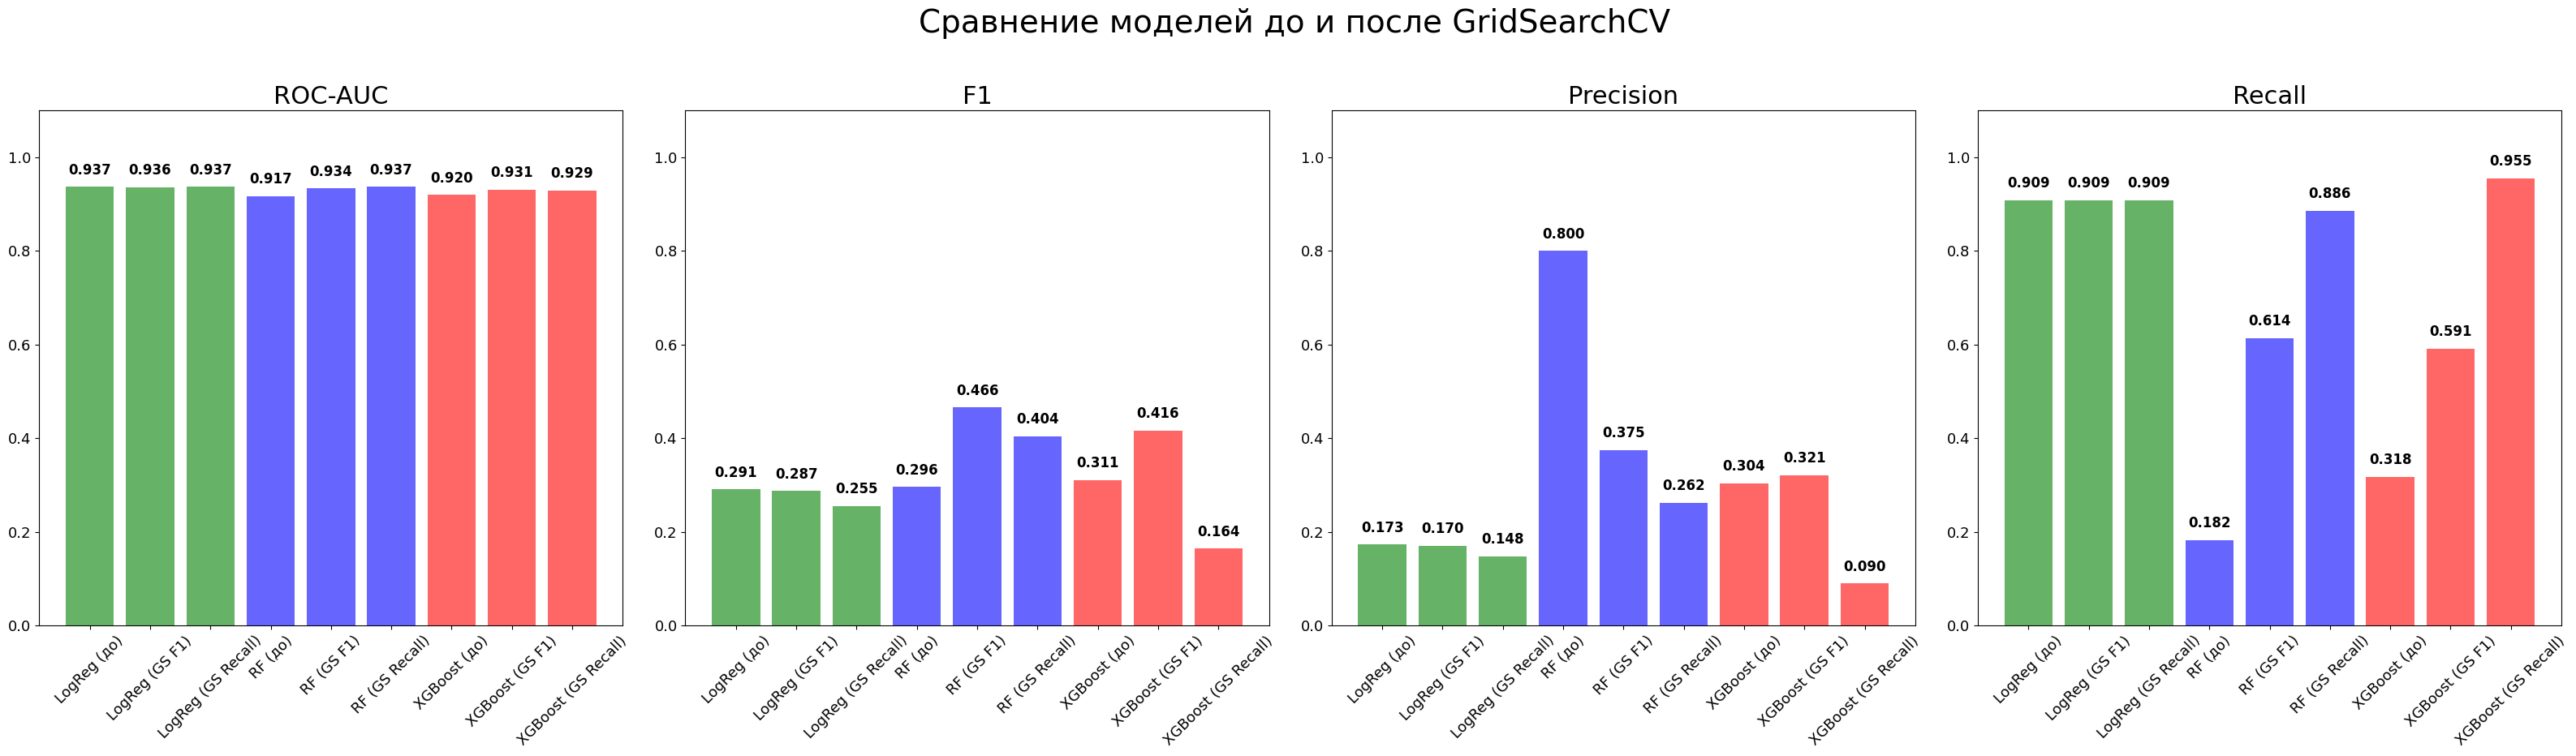

In [59]:





metrics = ['ROC-AUC', 'F1', 'Precision', 'Recall']

colors = ['green', 'green','green', 'blue', 'blue', 'blue','red', 'red', 'red']

fig, axes = plt.subplots(1, 4, figsize=(32, 9))

for ax, metric in zip(axes, metrics):
    values = df_comparison_3[metric].values
    labels = df_comparison_3.index

    bars = ax.bar(labels, values, color=colors, alpha=0.6)

    ax.set_title(metric, fontsize=22)
    ax.set_ylim(0, 1.1)

    ax.tick_params(axis='x', labelrotation=45, labelsize=13)
    ax.tick_params(axis='y', labelsize=13)

    for bar, value in zip(bars, values):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            value + 0.02,
            f'{value:.3f}',
            ha='center',
            va='bottom',
            fontsize=12,
            fontweight='bold',
        )

fig.suptitle(
    'Сравнение моделей до и после GridSearchCV',
    fontsize=28,
    y=1.03
)

plt.tight_layout()
plt.show()